# The Time Diversification Effect

In [1]:
import pandas as pd
import numpy as np
import random
from matplotlib import pyplot as plt
import seaborn as sns
from datetime import date
from dateutil.relativedelta import relativedelta

from trading_algos import optimization as tao
from trading_algos import datasets as tad
from trading_algos import plots as tap
from trading_algos import utils as tau
from trading_algos.utils import head_tail as ht

%load_ext autoreload
%autoreload 2

2026-05-26 21:46:11.584 | INFO     | trading_algos.config:<module>:11 - PROJ_ROOT path is: /home/jamie/code/JamieW365/trading_algos


## Load Data

In [2]:
# Load a complete collection of S&P500 stocks from repository
# Not interested in survivors here
df_stocks = tad.get_sp500(survivors=False)

In [3]:
ht(df_stocks)

Price            Close                                                       \
Ticker               A         AA    AAL        AAP        AAPL        ABBV   
Date                                                                          
1962-01-02         NaN   1.473408    NaN        NaN         NaN         NaN   
1962-01-03         NaN   1.495946    NaN        NaN         NaN         NaN   
1962-01-04         NaN   1.495946    NaN        NaN         NaN         NaN   
2026-03-12  111.629997  65.930000  10.55  52.660000  255.759995  225.369995   
2026-03-13  111.510002  63.590000  10.30  51.730000  250.119995  219.679993   
2026-03-16  111.830002  66.599998  10.49  53.189999  252.820007  221.449997   

Price                                              ...    Volume             \
Ticker            ABNB ABS         ABT       ACGL  ...       XOM       XRAY   
Date                                               ...                        
1962-01-02         NaN NaN         NaN        NaN  ...    902400        NaN   
1962-01-03         NaN NaN         NaN        NaN  ...   1200000        NaN   
1962-01-04         NaN NaN         NaN        NaN  ...   1088000        NaN   
2026-03-12  127.699997 NaN  108.139999  94.220001  ...  26054000  4793400.0   
2026-03-13  126.300003 NaN  108.029999  93.470001  ...  22414100  5267000.0   
2026-03-16  128.320007 NaN  109.949997  93.699997  ...  14735861  3467391.0   

Price                                                                      \
Ticker          XRX        XYL        XYZ        YUM        ZBH      ZBRA   
Date                                                                        
1962-01-02    51233        NaN        NaN        NaN        NaN       NaN   
1962-01-03    51233        NaN        NaN        NaN        NaN       NaN   
1962-01-04   198099        NaN        NaN        NaN        NaN       NaN   
2026-03-12  2359700  1626400.0  8599800.0  1781000.0  3184500.0  849300.0   
2026-03-13  2888800  1842200.0  7134200.0  1119600.0  1818300.0  755500.0   
2026-03-16  3141624  1646872.0  6071738.0  2191490.0  1955785.0  577565.0   

Price                             
Ticker           ZION        ZTS  
Date                              
1962-01-02        NaN        NaN  
1962-01-03        NaN        NaN  
1962-01-04        NaN        NaN  
2026-03-12  1579700.0  3955100.0  
2026-03-13  1412900.0  3783200.0  
2026-03-16  1029592.0  3665230.0  

[6 rows x 3300 columns]

In [4]:
df_stocks.shape

(16158, 3300)

In [5]:
print(df_stocks.columns.get_level_values(1).nunique(), 'stocks')

660 stocks


## Simulating Portfolios

In [5]:
df_prices = df_stocks.Close
ht(df_prices)

Ticker,A,AA,AAL,AAP,AAPL,ABBV,ABNB,ABS,ABT,ACGL,...,XOM,XRAY,XRX,XYL,XYZ,YUM,ZBH,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,NaN,1.473408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.088754,NaN,0.635471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-03,NaN,1.495946,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.090072,NaN,0.647386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-04,NaN,1.495946,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.090292,NaN,0.643414,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-12,111.629997,65.930000,10.55,52.660000,255.759995,225.369995,127.699997,NaN,108.139999,94.220001,...,153.529999,11.80,1.710000,120.019997,59.900002,158.460007,92.589996,204.050003,54.240002,115.459999
2026-03-13,111.510002,63.590000,10.30,51.730000,250.119995,219.679993,126.300003,NaN,108.029999,93.470001,...,156.119995,11.54,1.660000,119.879997,59.790001,160.399994,93.199997,202.720001,53.099998,115.620003
2026-03-16,111.830002,66.599998,10.49,53.189999,252.820007,221.449997,128.320007,NaN,109.949997,93.699997,...,157.229996,11.73,1.540000,121.070000,59.849998,161.779999,93.300003,203.970001,53.540001,118.150002


In [6]:
import seaborn as sns

<Axes: >

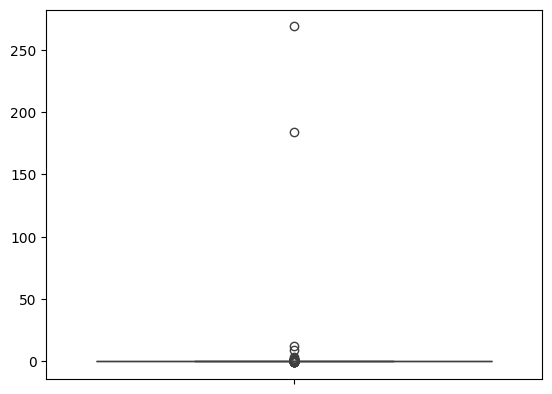

In [60]:


sns.boxplot(((df_prices / df_prices.shift(252)) - 1).mean())

<Axes: >

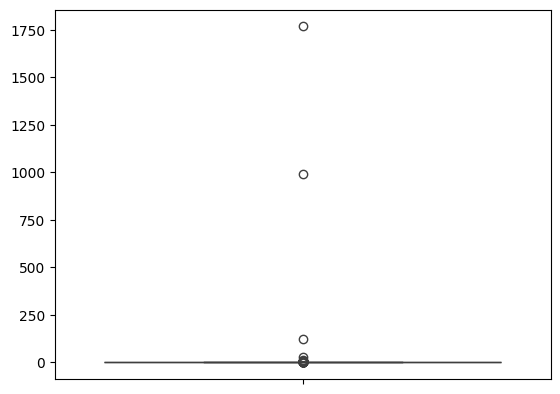

In [58]:
sns.boxplot(((df_prices / df_prices.shift(252)) - 1).std())

In [66]:
((df_prices / df_prices.shift(252)) - 1).mean().sort_values(ascending=False).head(10)

Ticker
TIE     268.673112
CBE     183.866681
SNDK     12.180715
CFC       9.262734
MEE       3.289052
BMC       2.143751
APP       1.759907
CVNA      1.546274
GEV       1.532278
GME       1.367502
dtype: float64

In [67]:
((df_prices / df_prices.shift(252)) - 1).std().sort_values(ascending=False).head(15)

Ticker
CBE     1767.814713
TIE      993.374985
CFC      122.585934
RSH       25.948975
MEE       12.134319
CPWR       7.432899
GME        6.933710
BMC        6.035602
AXON       5.297288
MI         4.032828
EP         2.529459
APP        2.341849
CVNA       2.341137
NVR        2.275606
TMC        2.158973
dtype: float64

In [11]:
problem_stocks = ((df_prices / df_prices.shift(252)) - 1).std().sort_values(ascending=False).head(20).index

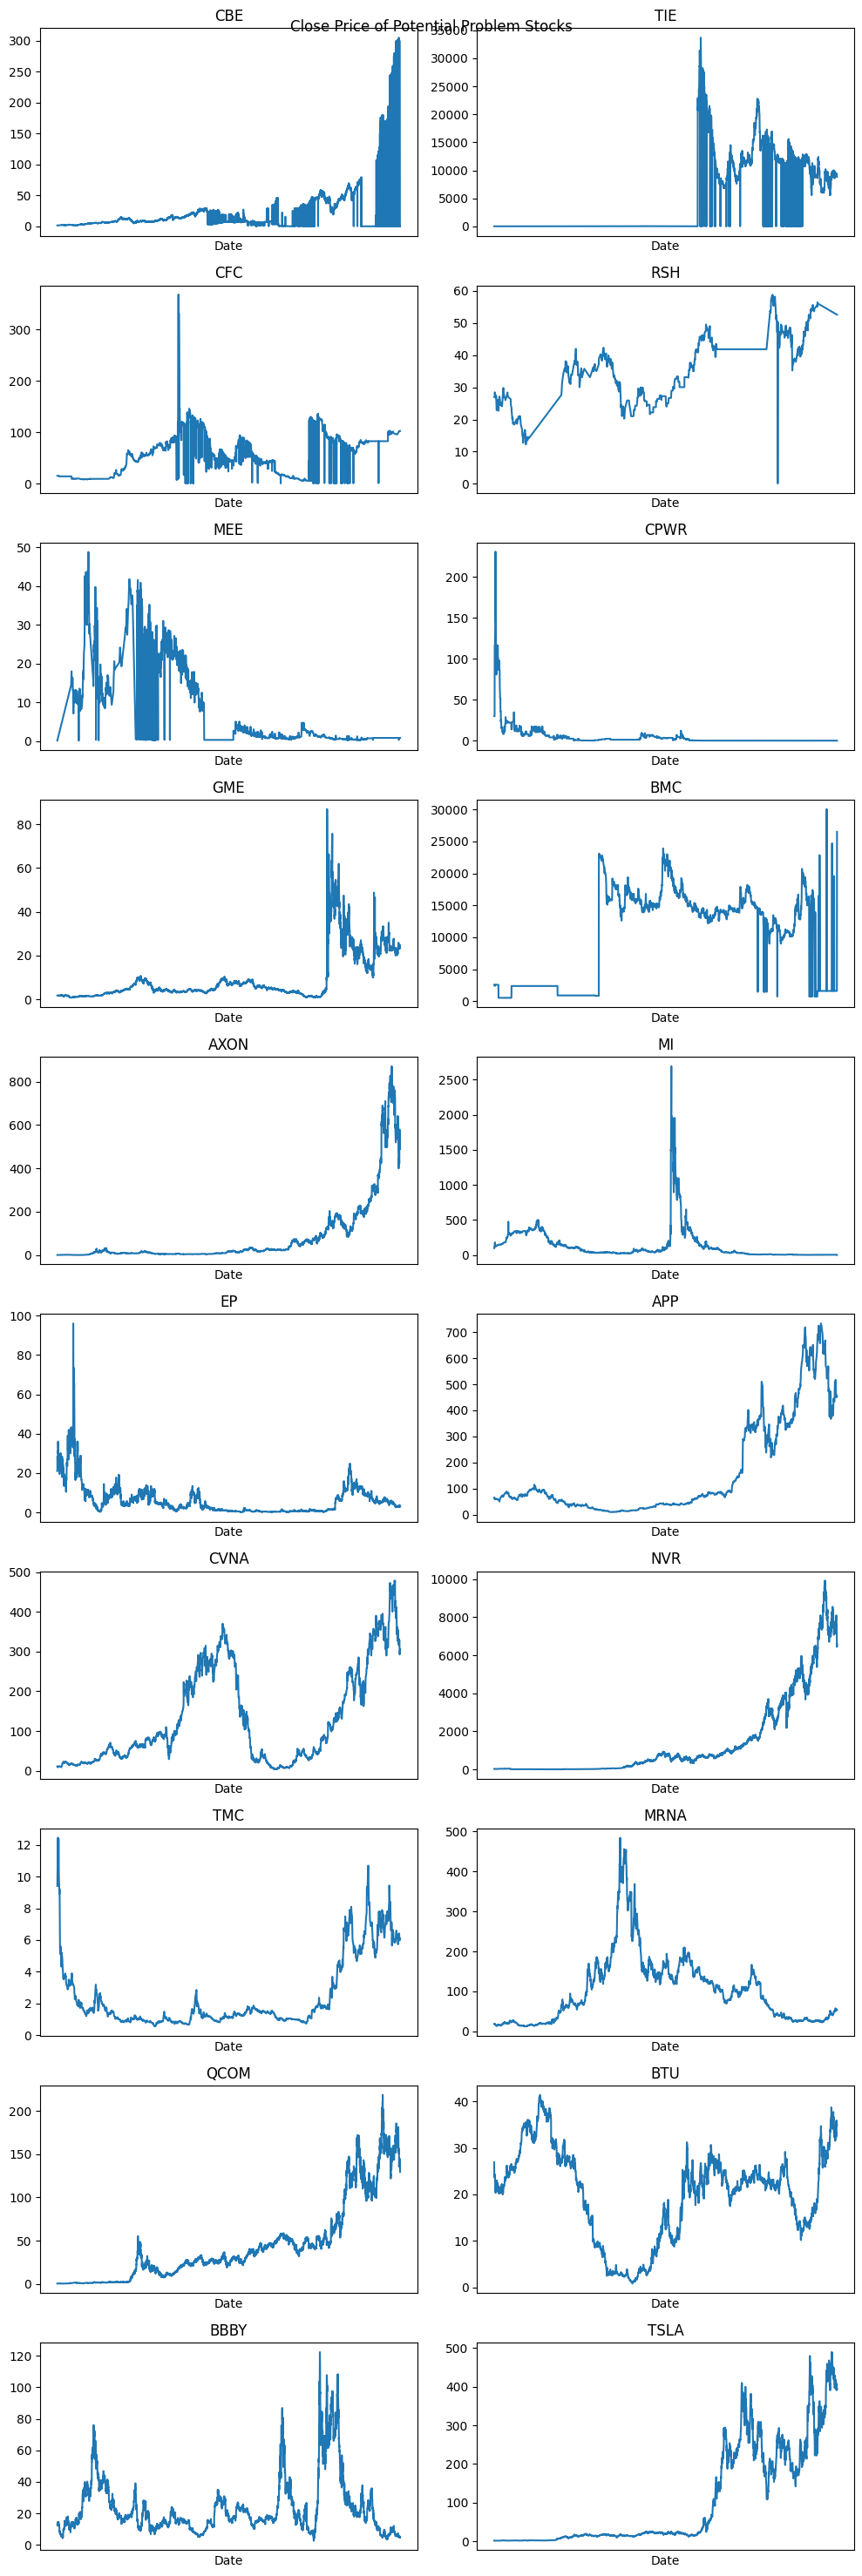

In [26]:
fig, ax = plt.subplots(10,2,figsize=(10, 30), tight_layout=True)

fig.suptitle('Close Price of Potential Problem Stocks')

for i, stock in enumerate(problem_stocks):

    ax_p = ax[int(((i*10)/ len(problem_stocks))), i%2]
    ax_p.set_title(stock)
    ax_p.set_xticks([])
    ax_p.set_xlabel('')
    ax_p.set_ylabel('')
    df_prices[df_prices[stock].notna()][stock].plot(ax=ax_p)

<Axes: xlabel='Date'>

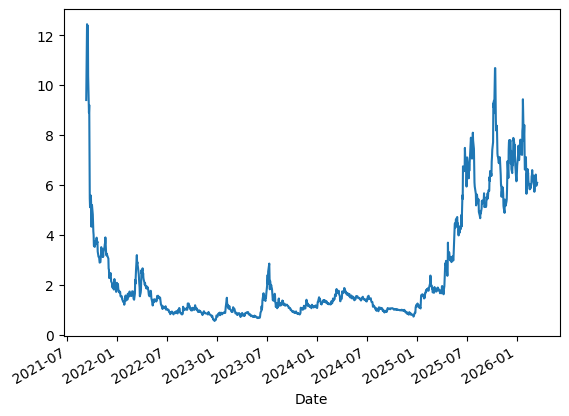

In [81]:
df_prices[df_prices['TMC'].notna()]['TMC'].plot()

In [23]:
for i in range(1,30+1):
    
    cagr_rolling = ((df_prices / df_prices.shift(i * 252)) ** (1 / i)) - 1
    print('Years: ', i, ' CAGR: ', cagr_rolling.mean().mean(), ' Risk: ', cagr_rolling.std().mean())

Years:  1  CAGR:  0.9482724131066466  Risk:  5.004522708160416
Years:  2  CAGR:  0.16805417370326972  Risk:  0.32265679627393085
Years:  3  CAGR:  0.13952010388898428  Risk:  0.21256776087669663
Years:  4  CAGR:  0.1294814113790769  Risk:  0.16587088764862157
Years:  5  CAGR:  0.12840389722475815  Risk:  0.14060179458749497
Years:  6  CAGR:  0.12625787919279693  Risk:  0.11828770910486494
Years:  7  CAGR:  0.12693973868731778  Risk:  0.10443798363794891
Years:  8  CAGR:  0.1272091207953516  Risk:  0.09374576291241792
Years:  9  CAGR:  0.1269408407006321  Risk:  0.08572403055347522
Years:  10  CAGR:  0.12633803670836505  Risk:  0.07855914132767627
Years:  11  CAGR:  0.12704819500740777  Risk:  0.07248485000361157
Years:  12  CAGR:  0.12675695722065888  Risk:  0.06794843898319718
Years:  13  CAGR:  0.12725200477703663  Risk:  0.06245185741535736
Years:  14  CAGR:  0.12607676222141262  Risk:  0.05779340897678531
Years:  15  CAGR:  0.12497843668052024  Risk:  0.0543253477604363
Years:  16 

In [ ]:
cagr_rolling = ((df_prices / df_prices.shift(i * 252)) ** (1 / i)) - 1

In [20]:
cagr_rolling.std()

Ticker
A            NaN
AA      0.035736
AAL          NaN
AAP          NaN
AAPL    0.027344
          ...   
YUM          NaN
ZBH          NaN
ZBRA    0.023847
ZION    0.017232
ZTS          NaN
Length: 660, dtype: float64

In [7]:
df_stocks.columns.get_level_values(1).unique()

Index(['A', 'AA', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABNB', 'ABS', 'ABT', 'ACGL',
       ...
       'XOM', 'XRAY', 'XRX', 'XYL', 'XYZ', 'YUM', 'ZBH', 'ZBRA', 'ZION',
       'ZTS'],
      dtype='object', name='Ticker', length=660)

In [ ]:
years = np.arange(1,31)
years

In [ ]:
df_y = (((df_prices / df_prices.shift(5*252))**(1/(5))) - 1).agg({'mean', 'std'}).rename({'mean':'CAGR','std':'Ann. Risk'})
df_y.loc['Sharpe'] = df_y.loc['CAGR'] / df_y.loc['Ann. Risk']
df_y.loc['Tot. Growth'] = ((1 + df_y.loc['Ann. Risk']) ** 5) - 1
df_y['Y'] = 5
df_y

In [ ]:
df_y

In [ ]:
df_y.reset_index(names='Summary').set_index(['Y', 'Summary'])#.T

In [ ]:
df_diversification = pd.DataFrame()

for y in np.arange(1,31):
    
    df_y = (df_prices / df_prices.shift(y*252)) ** (1 / y) - 1\
        .agg({'mean', 
              'std'})\
            .rename({'mean':'CAGR',
                     'std':'Ann Risk'})
    df_y.loc['Sharpe'] = df_y.loc['CAGR'] / df_y.loc['Ann Risk']
    df_y.loc['Inv Growth'] = ((1 + df_y.loc['CAGR'])**y) - 1
    df_y['Years Held'] = y
    df_y = df_y.reset_index(names='Summary').set_index(['Years Held', 'Summary'])
    df_diversification = pd.concat([df_diversification, df_y])

In [ ]:
df_diversification

In [ ]:
df_y.reset_index(names='Summary').set_index(['Y', 'Summary'])

In [ ]:
df_diversification.T.mean().loc[2:, 'Inv Growth'].plot()

In [ ]:
years_held = []
cagr = []
risk = []
ret = []
sharpe = []
act_growth = []

for y in range(1, 31):

    # 252 trading days in an average year
    trading_periods = y*252

    df_returns = (((df_prices / df_prices.shift(trading_periods))**(1/(y))) - 1)
    inv_cagr = df_returns.mean()
    cagr.append(inv_cagr)
    risk.append(df_returns.std())


In [ ]:
len(risk)

In [ ]:
plt.plot(var[12:])

In [ ]:
years = np.arange(1,31)
cagr = []

df_cagr = pd.DataFrame({'Years Held':years})

for y in years:
    
    trading_days = y*252

    # Compute rolling CAGR
    df_cagr.iloc[y-1] = cagr.append((((df_prices / df_prices.shift(trading_days))**(1/y)) - 1).mean().values.tolist())

In [ ]:
df_cagr